# Edit Flows: Discrete Flow Matching with Edit Operations

Here, I replicate the **"Edit Flows: Flow Matching with Edit Operations"** paper by [Havasi et al.](https://arxiv.org/abs/2506.09018) which introduces a non-factorized probability path model for discrete flow matching via insertions, deletions, and substitutions.

#### Dataset Overview

In [ ]:
import torch
from torch.utils.data import Dataset

class FairseqStyleTextDataset(Dataset):
    def __init__(self, src_path, tgt_path, dict_path, add_bos=True, add_eos=True):
        # 1) load dictionary
        SPECIAL_OFFSET = 4     # pad, unk, bos, eos 4개

        self.tok2idx = {}
        self.tok2idx["<pad>"] = 0
        self.tok2idx["<unk>"] = 1
        self.tok2idx["<s>"]   = 2
        self.tok2idx["</s>"]  = 3

        with open(dict_path, 'r', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                if line.strip() == "":
                    continue
                tok = line.split()[0]
                self.tok2idx[tok] = idx + SPECIAL_OFFSET

        self.bos = self.tok2idx.get("<s>", None)
        self.eos = self.tok2idx.get("</s>", None)
        self.unk = self.tok2idx.get("<unk>", None)

        self.add_bos = add_bos
        self.add_eos = add_eos

        # 2) load src/tgt text lines
        with open(src_path, 'r', encoding='utf-8') as f:
            self.src_lines = [line.strip() for line in f]

        with open(tgt_path, 'r', encoding='utf-8') as f:
            self.tgt_lines = [line.strip() for line in f]

        assert len(self.src_lines) == len(self.tgt_lines)

    def encode(self, line):
        # 3) split tokens (BPE tokens already pre-split)
        tokens = line.split()

        # 4) numericalize
        ids = []
        if self.add_bos and self.bos is not None:
            ids.append(self.bos)

        for t in tokens:
            ids.append(self.tok2idx.get(t, self.unk))

        if self.add_eos and self.eos is not None:
            ids.append(self.eos)

        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        src_ids = self.encode(self.src_lines[idx])
        tgt_ids = self.encode(self.tgt_lines[idx])
        return {
            "id": idx,
            "source": src_ids,
            "target": tgt_ids,
            "src_len": src_ids.size(0),
            "tgt_len": tgt_ids.size(0),
        }

    def __len__(self):
        return len(self.src_lines)

def collate_fn(samples):
    if len(samples) == 0:
        return {}

    src_lengths = torch.tensor([s["src_len"] for s in samples], dtype=torch.long)
    tgt_lengths = torch.tensor([s["tgt_len"] for s in samples], dtype=torch.long)

    max_src = src_lengths.max().item()
    max_tgt = tgt_lengths.max().item()

    pad_idx = 1  # fairseq default: 1 = <pad>

    bs = len(samples)
    src_batch = torch.full((bs, max_src), pad_idx, dtype=torch.long)
    tgt_batch = torch.full((bs, max_tgt), pad_idx, dtype=torch.long)

    for i, s in enumerate(samples):
        src = s["source"]
        tgt = s["target"]
        src_batch[i, : src.size(0)] = src
        tgt_batch[i, : tgt.size(0)] = tgt

    return {
        "id": torch.tensor([s["id"] for s in samples]),
        "net_input": {
            "src_tokens": src_batch,
            "src_lengths": src_lengths,
        },
        "target": tgt_batch,
    }

from torch.utils.data import DataLoader

dataset = FairseqStyleTextDataset(
    "./datasets/USPTO_50K/aug20/train.src",
    "./datasets/USPTO_50K/aug20/train.tgt",
    "./datasets/USPTO_50K/dict.txt",
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_sinusoidal_sequence(
    L: int,
    noise: float,
    num_cycles_fn=lambda: np.random.uniform(1.5, 3.5),
    x_int_fn=lambda: np.random.uniform(0, 2*np.pi),
) -> np.ndarray:
    """Generate y = 0.5 * sin(B(x - C)) + 0.5 with optional Gaussian noise."""

    x = np.linspace(0, 4*np.pi, L)                  # [L]
    cycles = num_cycles_fn()
    B = cycles / 2                                  # frequency
    C = x_int_fn()
    y = 0.5 * np.sin(B * (x - C)) + 0.5             # [L]
    if noise > 0:
        y += np.random.normal(0, noise, L)          # [L]
    return y                                        # [L]

def plot_sequences(xs, title="Sequences", pad_token=None):
    plt.figure(figsize=(8,4)); plt.title(title); plt.xlabel("Index"); plt.ylabel("Value"); plt.grid()
    colors = plt.cm.viridis(np.linspace(0,1,len(xs)))
    for i, y in enumerate(xs):
        if pad_token is not None: y = y[y != pad_token]
        plt.scatter(range(len(y)), y, s=10, c=[colors[i]])
    plt.tight_layout(); plt.show()

#### Training Edit Flow Models



#### Model

In [2]:
# Helper functions
from typing import Tuple, cast
from torchtyping import TensorType as T

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from flow import KappaScheduler, Coupling, EmptyCoupling, sample_p

BOS_TOKEN = 128
PAD_TOKEN = 129
GAP_TOKEN = 130

def _align_pair(seq0: torch.Tensor, seq1: torch.Tensor):
    """Return two aligned sequences using minimum-edit dynamic programming."""
    
    seq0 = seq0.cpu().numpy()
    seq1 = seq1.cpu().numpy()
    m, n = len(seq0), len(seq1)
    
    # DP table
    dp = [[i + j for j in range(n + 1)] for i in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq0[i-1] == seq1[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])   # delete, insert, substitute

    # Backtracking
    aligned_0, aligned_1 = [], []
    i, j = m, n
    while i > 0 or j > 0:
        # Case 1: match / substitute (prefer match)
        if i > 0 and j > 0 and dp[i][j] == dp[i-1][j-1] + (seq0[i-1] != seq1[j-1]):
            aligned_0.append(seq0[i-1])
            aligned_1.append(seq1[j-1])
            i -= 1
            j -= 1
            continue
        # Case 2: delete (seq0 element unmatched)
        if i > 0 and dp[i][j] == dp[i-1][j] + 1:
            aligned_0.append(seq0[i-1])
            aligned_1.append(GAP_TOKEN)
            i -= 1
            continue
        # Case 3: insert (seq1 element unmatched)
        aligned_0.append(GAP_TOKEN)
        aligned_1.append(seq1[j-1])
        j -= 1

    return aligned_0[::-1], aligned_1[::-1]

def opt_align_xs_to_zs(x_0: torch.Tensor, x_1: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Aligns x_0 and x_1 to the same length by using a dynamic programming approach
    to find the minimum edit distance alignment.
    """
    aligned_pairs = [_align_pair(x_0[b], x_1[b]) for b in range(x_0.shape[0])]
    x_0_aligned = torch.stack(
        [torch.tensor(pair[0], dtype=x_0.dtype, device=x_0.device) for pair in aligned_pairs])
    x_1_aligned = torch.stack(
        [torch.tensor(pair[1], dtype=x_1.dtype, device=x_1.device) for pair in aligned_pairs])
    return x_0_aligned, x_1_aligned

# --------
def sample_cond_pt(p0: torch.Tensor, p1: torch.Tensor, t: torch.Tensor, kappa: KappaScheduler):
    t = t.reshape(-1, 1, 1)
    pt = (1 - kappa(t)) * p0 + kappa(t) * p1
    return sample_p(pt)

def make_x0_like_x1(
    x1: torch.Tensor,
    vocab_size: int = 128,
    pad_token: int = PAD_TOKEN,
    noise: float = 0.05,
    **kwargs,
) -> torch.Tensor:
    batch_size, x1_max_len = x1.shape
    x0s = []
    for i in range(batch_size):
        x1i_len = (x1[i] != pad_token).sum().item()
        x0i = torch.Tensor(make_sinusoidal_sequence(int(x1i_len), noise=noise, **kwargs))
        x0i = torch.round(torch.clip(x0i * vocab_size, min=0.0, max=vocab_size-1)).long()
        x0i = F.pad(x0i, (0, x1_max_len - x0i.shape[0]), value=pad_token)
        x0s.append(x0i)
    x0s = torch.stack(x0s, dim=0).long()  # (batch_size, x1_max_len)
    assert x0s.shape == x1.shape, "x0 and x1 must have the same shape"
    return x0s

def make_x0_with_bounds(
    batch_size: int = 2,
    min_length: int = 96,
    max_length: int = 96,
    vocab_size: int = 128,
    pad_token: int = PAD_TOKEN,
    noise: float = 0.05,
    **kwargs
) -> torch.Tensor:
    
    lengths = np.random.randint(min_length, max_length+1, size=(batch_size,))
    max_seq_len = lengths.max()
    x0s = []
    for length in lengths:
        x0i = torch.Tensor(make_sinusoidal_sequence(length, noise=noise, **kwargs))
        x0i = torch.round(torch.clip(x0i * vocab_size, min=0.0, max=vocab_size-1)).long()
        x0i = F.pad(x0i, (0, max_seq_len - x0i.shape[0]), value=pad_token)
        x0s.append(x0i)
    x0s = torch.stack(x0s, dim=0).long()  # (batch_size, max_seq_len)
    assert x0s.shape[1] == max_seq_len
    assert x0s.shape[0] == batch_size
    return x0s

def make_batch(
    batch_size: int = 2,
    min_length: int = 96,
    max_length: int = 96,
    vocab_size: int = 128,
    pad_token: int = PAD_TOKEN,
    bos_token: int = BOS_TOKEN,
    coupling: Coupling = EmptyCoupling(),
    seq_align_fn = opt_align_xs_to_zs,
    noise: float = 0.05,
    **kwargs,
):
    # 1) 랜덤 길이 생성
    lengths = np.random.randint(min_length, max_length + 1, size=batch_size)

    x0_list, x1_list, z0_list, z1_list = [], [], [], []

    # 2) 각 시퀀스 생성 + coupling + alignment
    for L in lengths:
        s = make_sinusoidal_sequence(L, noise=noise, **kwargs)
        x1 = torch.from_numpy(np.clip(np.round(s * vocab_size), 0, vocab_size - 1)).long().unsqueeze(0)  # [1, L]
        x0, _ = coupling.sample(x1)            # sampled x0: [1, L0]
        z0, z1 = seq_align_fn(x0, x1)          # list[int], list[int]
        
        x1_list.append(x1.squeeze(0))
        x0_list.append(x0.squeeze(0))
        z1_list.append(torch.tensor(z1, dtype=torch.long))
        z0_list.append(torch.tensor(z0, dtype=torch.long))

    # 3) 각 종류별 max length 계산
    x0_max = max(len(x) for x in x0_list)
    x1_max = max(len(x) for x in x1_list)
    z_max  = max(len(z) for z in z1_list)
    assert z_max == max(len(z) for z in z0_list)

    # 4) <PAD> token 추가
    def pad_stack(seq_list, max_len):
        fixed = [s.view(-1) for s in seq_list]  # ★ 1D 강제
        return torch.stack([F.pad(s, (0, max_len - s.size(0)), value=pad_token) for s in fixed], dim=0).long()
    x0 = pad_stack(x0_list, x0_max)
    x1 = pad_stack(x1_list, x1_max)
    z0 = pad_stack(z0_list, z_max)
    z1 = pad_stack(z1_list, z_max)

    # 5) BOS token prepend
    def add_bos(x):
        return F.pad(x, (1, 0), value=bos_token)
    x0 = add_bos(x0)
    x1 = add_bos(x1)
    z0 = add_bos(z0)
    z1 = add_bos(z1)

    # 6) 타임스텝 + 패딩 마스크
    t = torch.rand(batch_size, 1)
    pad_mask = (x1 == pad_token)

    return x0, x1, z0, z1, t, pad_mask

def make_ut_mask_from_z(
    z_t: T["batch_size", "z_seq_len", "long"],
    z_1: T["batch_size", "z_seq_len", "long"],
    vocab_size: int = 130,
    pad_token: int = PAD_TOKEN,
    gap_token: int = GAP_TOKEN,
) -> T["batch_size", "z_seq_len", "n_ops", "bool"]:
    
    """
    Create a mask for u_cat for indexing the output rate tensor based on differences between z_t and z_1.
    For each position i where z_t and z_1 differ, we index as follows:

    - z_t[i] = GAP_TOKEN & z_1[i] = c => u_mask[i, insert, c] = 1
    - z_t[i] = c & z_1[i] = GAP_TOKEN => u_mask[i, delete] = 1
    - z_t[i] = c1 & z_1[i] = c2 => u_mask[i, substitute, c1, c2] = 1
    """
    batch_size, z_seq_len = z_t.shape
    n_ops = 2 * vocab_size + 1  # insert + substitute + delete

    z_neq = (z_t != z_1) & (z_t != pad_token) & (z_1 != pad_token)
    z_ins = (z_t == gap_token) & (z_1 != gap_token) & z_neq         # (batch_size, z_seq_len)
    z_del = (z_t != gap_token) & (z_1 == gap_token) & z_neq         # (batch_size, z_seq_len)
    z_sub = z_neq & ~z_ins & ~z_del                                 # (batch_size, z_seq_len) 

    # mask (batch_size, z_seq_len, u_ops) where 1 indicates operation that bring z_t closer to z_1
    u_mask = torch.zeros((batch_size, z_seq_len, n_ops), dtype=torch.bool, device=z_t.device)
    u_mask[z_ins, z_1[z_ins]] = True
    u_mask[z_sub, z_1[z_sub] + vocab_size] = True
    u_mask[:,:,-1][z_del] = True

    assert z_neq.sum() == (z_ins | z_del | z_sub).sum(), "Mismatch in number of edits"
    assert z_neq.sum() == u_mask.sum(), "Mismatch in number of edits in mask"

    return cast(T["batch_size", "z_seq_len", "n_ops", "bool"], u_mask)

def fill_gap_tokens_with_repeats(
    x_ut: torch.Tensor,
    z_gap_mask: torch.Tensor,
    z_pad_mask: torch.Tensor,
):
    batch_size, _ = z_gap_mask.shape
    _, x_seq_len, _ = x_ut.shape

    # Use cumsum on non-gap positions to point to the last valid non-gap position
    non_gap_mask = ~z_gap_mask  # Invert mask to get non-gap positions
    indices = non_gap_mask.cumsum(dim=1) - 1        # (batch_size, z_seq_len)
    indices = indices.clamp(min=0, max=x_seq_len-1) # Ensure indices are within bounds

    # Use indices to gather from x_ut
    batch_indices = torch.arange(batch_size, device=x_ut.device).unsqueeze(1)
    result = x_ut[batch_indices, indices]   # (batch_size, z_seq_len, vocab_size)
    result[z_pad_mask] = 0                  # Set pad positions to 0
    return result


/root/miniconda3/envs/310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def rm_gap_tokens(z: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Remove gap tokens from a batched tensor and right-pad with PAD_TOKEN.
    """    
    batch_size, _ = z.shape
    z_no_gap = []
    for b in range(batch_size):
        z_no_pad = z[b][z[b] != PAD_TOKEN]
        z_no_gap.append(z_no_pad[z_no_pad != GAP_TOKEN])
    max_len = max(len(z) for z in z_no_gap)
    x = torch.stack([F.pad(z, (0, max_len - len(z)), value=PAD_TOKEN) for z in z_no_gap], dim=0).long()
    x_pad_mask = (x == PAD_TOKEN)
    z_gap_mask = (z == GAP_TOKEN)
    z_pad_mask = (z == PAD_TOKEN)
    assert ((~x_pad_mask).sum(1) + z_gap_mask.sum(1)).equal((~z_pad_mask).sum(1))
    return x, x_pad_mask, z_gap_mask, z_pad_mask

def safe_chr(c: int, show_special_chars=False, compact=False) -> str:
    if c == GAP_TOKEN:
        return 'Δ' if compact else '<GAP>'
    elif c == PAD_TOKEN:
        return 'π' if compact else '<PAD>'
    elif c == BOS_TOKEN:
        return '<BOS>'
    try:
        ch = chr(c)
        # Replace non-printable or whitespace (except space) with '.'
        if ch.isprintable() and (ch == ' ' or not ch.isspace()):
            return ch
        elif show_special_chars:
            return repr(ch)
        else:
            return '.'
    except Exception:
        return '.'

def pretty_parse(x: torch.Tensor, **kwargs) -> str:
    x_str = ''.join(safe_chr(int(c), **kwargs) for c in x.cpu().numpy().flatten())
    return x_str

def pretty_print(x: torch.Tensor, **kwargs) -> None:
    """
    Pretty print a tensor as an ascii string with gap tokens represented as '-'
    Non-printable/special characters (including line breaks, tabs, etc.) are replaced with '.'
    """
    print(pretty_parse(x, **kwargs))

In [4]:
# Basic Transformer model architecture for edit flows

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.H = hidden_dim
        half = hidden_dim // 2
        inv_freq = torch.exp(-torch.arange(half, dtype=torch.float32) * (math.log(10000) / (half - 1)))
        self.register_buffer("inv_freq", inv_freq)  # [H/2]

    def forward(self, t: torch.Tensor) -> torch.Tensor:  # t: [B,1]
        if t.dim() == 1:
            t = t.unsqueeze(1)  # [B,1]

        x = t.float() * self.inv_freq.unsqueeze(0)      # [B, H/2]
        emb = torch.cat([torch.sin(x), torch.cos(x)], dim=-1)  # [B, H or H-1]
        if self.H % 2 == 1:
            emb = torch.nn.functional.pad(emb, (0, 1))         # [B, H]
        return emb  # [B, H]


class SimpleEditFlowsTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        hidden_dim: int,
        num_layers: int,
        num_heads=8,
        max_seq_len=512,
        bos_token_id=128,
        pad_token_id=129,
    ):
        super().__init__()
        # self.vocab_size = vocab_size
        # self.hidden_dim = hidden_dim
        # self.num_layers = num_layers
        # self.num_heads = num_heads
        # self.max_seq_len = max_seq_len
        # self.bos_token_id = bos_token_id
        # self.pad_token_id = pad_token_id

        self.H = hidden_dim
        self.V = vocab_size
        self.pad_id = pad_token_id

        assert bos_token_id < vocab_size
        assert pad_token_id < vocab_size

        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, hidden_dim)
        self.pos_emb = nn.Embedding(max_seq_len, hidden_dim)
        self.time_emb = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Transformer
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=0.1,
                activation="gelu",
                batch_first=False,
            )
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(hidden_dim)

        # Projection heads
        self.rates_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
        )
        self.ins_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.sub_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(
        self,
        tokens: T["B","L","long"],
        t: T["B",1,"float"],
        pad_mask: T["B","L","bool"],
    ):
        B, L = tokens.shape
       
        # --- Embeddings ---
        tok = self.token_emb(tokens)                 # [B,L,H]
        tim = self.time_emb(t).unsqueeze(1).expand(B, L, -1)  # [B,L,H]
        pos = self.pos_emb(torch.arange(L, device=tokens.device))  # [L,H]
        pos = pos.unsqueeze(0).expand(B, L, -1)      # [B,L,H]

        x = tok + tim + pos                          # [B,L,H]
        
        # --- Transformer ---
        x = x.transpose(0, 1)                        # [L,B,H]
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=pad_mask)
        x = x.transpose(0, 1)                        # [B,L,H]
        x = self.norm(x)                             # [B,L,H]

        # --- Edit rate output ---
        rates = F.softplus(self.rates_head(x))       # [B,L,3]
        # rates = torch.clamp(rates, max=10.0)         # stability

        # --- Insert / Substitute token projections ---
        ins_h = self.ins_head(x)                     # [B,L,H]
        sub_h = self.sub_head(x)                     # [B,L,H]
        V_emb = self.token_emb.weight                # [V,H]
        ins_logits = torch.clamp((ins_h @ V_emb.T) / math.sqrt(self.H), -50, 50)   # [B,L,V], stability
        sub_logits = torch.clamp((sub_h @ V_emb.T) / math.sqrt(self.H), -50, 50)   # [B,L,V], stability
        # mask padded positions: -inf
        pad_inf = pad_mask.unsqueeze(-1)
        ins_logits = ins_logits.masked_fill(pad_inf, -1e9)
        sub_logits = sub_logits.masked_fill(pad_inf, -1e9)
        # probs
        ins = F.softmax(ins_logits, dim=-1)          # [B,L,V]
        sub = F.softmax(sub_logits, dim=-1)          # [B,L,V]
        
        # zero out padded positions
        valid = (~pad_mask).unsqueeze(-1).float()    # [B,L,1]
        rates = rates * valid                        # [B,L,3]
        ins = ins * valid                            # [B,L,V]
        sub = sub * valid                            # [B,L,V]

        # minimal NaN check (core only)
        if torch.isnan(x).any():
            raise ValueError("NaN in transformer output")

        return rates, ins, sub

### Training Objective

$$ \mathcal{L}(\theta) = \mathbb{E}_{t, p_t(x_t, z_t \mid z_0, z_1)}^{\pi(z_0, z_1)} \Bigg[\sum_{x \neq x_t} u_t^{\theta}(x \mid x_t) - \sum_{i=1}^{N} \mathbf{1}[z_1^{i} \neq z_t^{i}] \frac{\dot{\kappa}_t}{1 - \kappa_t} \log u_t^{\theta}\big(x(z_t, i, z_1^{i}) \mid x_t\big) \Bigg] $$


In [6]:
# Training loop

import sys
import hashlib
from tqdm import tqdm
from collections import defaultdict
from flow import CubicScheduler, EmptyCoupling, GeneratorCoupling, UniformCoupling, x2prob
from IPython.display import clear_output

torch.manual_seed(42)
np.random.seed(42)

metrics = defaultdict(list)

# Constants
V = 128
L = 128
batch_size = 128
min_seq_len, max_seq_len = 64, 128

# Functions
seq_align_fn = opt_align_xs_to_zs
num_cycles_fn = lambda: np.random.uniform(2.5, 4)
x_int_fn = lambda: np.random.uniform(0, 2 * np.pi)

generator_fn = lambda x1: make_x0_with_bounds(
    batch_size=int(x1.shape[0]),
    min_length=min_seq_len,
    max_length=max_seq_len,
    vocab_size=V,
    pad_token=PAD_TOKEN,
    num_cycles_fn=lambda: np.random.uniform(1., 2.5),
    x_int_fn=x_int_fn,
)

# Choose coupling
# coupling = EmptyCoupling()
coupling = GeneratorCoupling(generator_fn)
# coupling = UniformCoupling(min_len=min_seq_len, max_len=max_seq_len, mirror_len=True, vocab_size=V, pad_token=PAD_TOKEN)

scheduler = CubicScheduler(a=1.0, b=1.0)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

# Model
model = SimpleEditFlowsTransformer(
    vocab_size=V + 2,     # PAD + BOS
    hidden_dim=512,
    num_layers=8,
    num_heads=32,
    max_seq_len=2 * L,
    pad_token_id=V,
    bos_token_id=V + 1,
).to(device)
model.train()

optim = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training Loop
steps = 384000 // batch_size
pbar = tqdm(range(steps), desc="Training Edit Flows", unit="step")

for step in pbar:
    # 1) Sample batch & interpolate in Z space
    x0, x1, z0, z1, t, _ = make_batch(
        batch_size=batch_size,
        min_length=min_seq_len,
        max_length=max_seq_len,
        vocab_size=V,
        coupling=coupling,
        seq_align_fn=seq_align_fn,
        num_cycles_fn=num_cycles_fn,
        x_int_fn=x_int_fn,
    )

    zt = sample_cond_pt(
        x2prob(z0, V + 3),
        x2prob(z1, V + 3),
        t,
        scheduler,
    )
    # Remove gaps, pad, and get masks
    xt, x_mask, z_gap_mask, z_pad_mask = rm_gap_tokens(zt)
    assert (~x_mask).sum(1).max().item() == xt.shape[1]

    # 2) Compute uz_mask (which operations move z_t → z_1)  (B, ZL, 2V+1)
    uz_mask = make_ut_mask_from_z(
        zt, z1,  # [B,ZL]: int 
        vocab_size=V + 2,  # +2 for PAD and BOS tokens
    )

    # 3) Model forward
    ut, ins_p, sub_p = model(
        tokens=xt.to(device),
        t=t.to(device),
        pad_mask=x_mask.to(device),
    )
    λ_ins = ut[:, :, 0]       # Insertion rate        [B,L]
    λ_sub = ut[:, :, 1]       # Substitution rate     [B,L]
    λ_del = ut[:, :, 2]       # Deletion rate         [B,L]

    # Invariants
    assert ut[x_mask].sum() == 0
    assert ins_p[x_mask].sum() == 0
    assert sub_p[x_mask].sum() == 0
    assert sub_p[~x_mask].sum(-1).allclose(torch.ones_like(sub_p[~x_mask].sum(-1)))
    assert ins_p[~x_mask].sum(-1).allclose(torch.ones_like(ins_p[~x_mask].sum(-1)))
    assert not uz_mask[z_pad_mask].any()

    # 4) Construct local edit rates u_t(i, a)
    u_ins = λ_ins.unsqueeze(-1) * ins_p  # BLV
    u_sub = λ_sub.unsqueeze(-1) * sub_p  # BLV
    u_del = λ_del.unsqueeze(-1)          # BL1

    ux_cat = torch.cat([u_ins, u_sub, u_del], dim=-1)                      # B,L,2V+1
    uz_cat = fill_gap_tokens_with_repeats(ux_cat, z_gap_mask, z_pad_mask)  # B,L,2V+1
    u_tot = ut.sum(dim=(1, 2))                                             # B,

    # Numeric checks
    if torch.isnan(ux_cat).any():
        raise ValueError("NaN in ux_cat")
    if torch.isnan(uz_cat).any():
        raise ValueError("NaN in uz_cat")

    assert uz_cat.shape[1] == zt.shape[1]
    assert uz_cat.shape[1] >= ux_cat.shape[1]
    assert ux_cat[x_mask].sum() == 0
    assert uz_cat[z_pad_mask].sum() == 0
    assert (uz_cat < 0).sum() == 0

    # 5) Loss = Bregman divergence
    sched_coeff = (scheduler.derivative(t) / (1 - scheduler(t))).to(device)    

    eps = 1e-8
    safe_u = uz_cat.clamp(min=eps)
    log_u = torch.log(safe_u).clamp(min=-20)

    loss = u_tot - (log_u * uz_mask.to(device) * sched_coeff.unsqueeze(-1)).sum(dim=(1, 2))
    loss = loss.mean()

    assert not torch.isnan(loss)
    assert not torch.isinf(loss)

    optim.zero_grad()
    loss.backward()
    optim.step()

    metrics["loss"].append(loss.item())
    metrics["u_tot"].append(u_tot.mean().item())
    metrics["u_ins"].append(λ_ins.sum(dim=1).mean().item())
    metrics["u_del"].append(λ_del.sum(dim=1).mean().item())
    metrics["u_sub"].append(λ_sub.sum(dim=1).mean().item())
    metrics["u_con"].append((uz_cat * uz_mask.to(device)).sum(dim=(1, 2)).mean().item())

    if step % 50 == 0:
        # clear_output(wait=True)  # Clear previous output
        print(
            f"Step {step}: Loss={loss.item():.4f}, "
            f"u_tot={u_tot.mean().item():.4f}, "
            f"u_ins={metrics['u_ins'][-1]:.4f}, "
            f"u_del={metrics['u_del'][-1]:.4f}, "
            f"u_sub={metrics['u_sub'][-1]:.4f}, "
            f"u_con={metrics['u_con'][-1]:.4f}"
        )
        sys.stdout.flush()

Training Edit Flows:   0%|          | 0/3000 [00:00<?, ?step/s]/tmp/ipykernel_81239/3703577141.py:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z1_list.append(torch.tensor(z1, dtype=torch.long))
/tmp/ipykernel_81239/3703577141.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z0_list.append(torch.tensor(z0, dtype=torch.long))


Step 0: Loss=5.7512, u_tot=3.3375, u_ins=1.1138, u_del=1.1097, u_sub=1.1140, u_con=0.1860


Training Edit Flows:   2%|▏         | 50/3000 [00:33<32:14,  1.52step/s]

Step 50: Loss=5.0490, u_tot=1.1142, u_ins=0.4634, u_del=0.4318, u_sub=0.2191, u_con=0.1362


Training Edit Flows:   3%|▎         | 100/3000 [01:06<32:15,  1.50step/s]

...

Step 2200: Loss=5.6494, u_tot=0.9140, u_ins=0.4025, u_del=0.3609, u_sub=0.1506, u_con=0.0245


Training Edit Flows:  75%|███████▌  | 2250/3000 [25:15<07:59,  1.57step/s]

Step 2250: Loss=6.7358, u_tot=1.0395, u_ins=0.4605, u_del=0.3840, u_sub=0.1950, u_con=0.0401


Training Edit Flows:  76%|███████▋  | 2289/3000 [25:52<08:02,  1.47step/s]


KeyboardInterrupt: 

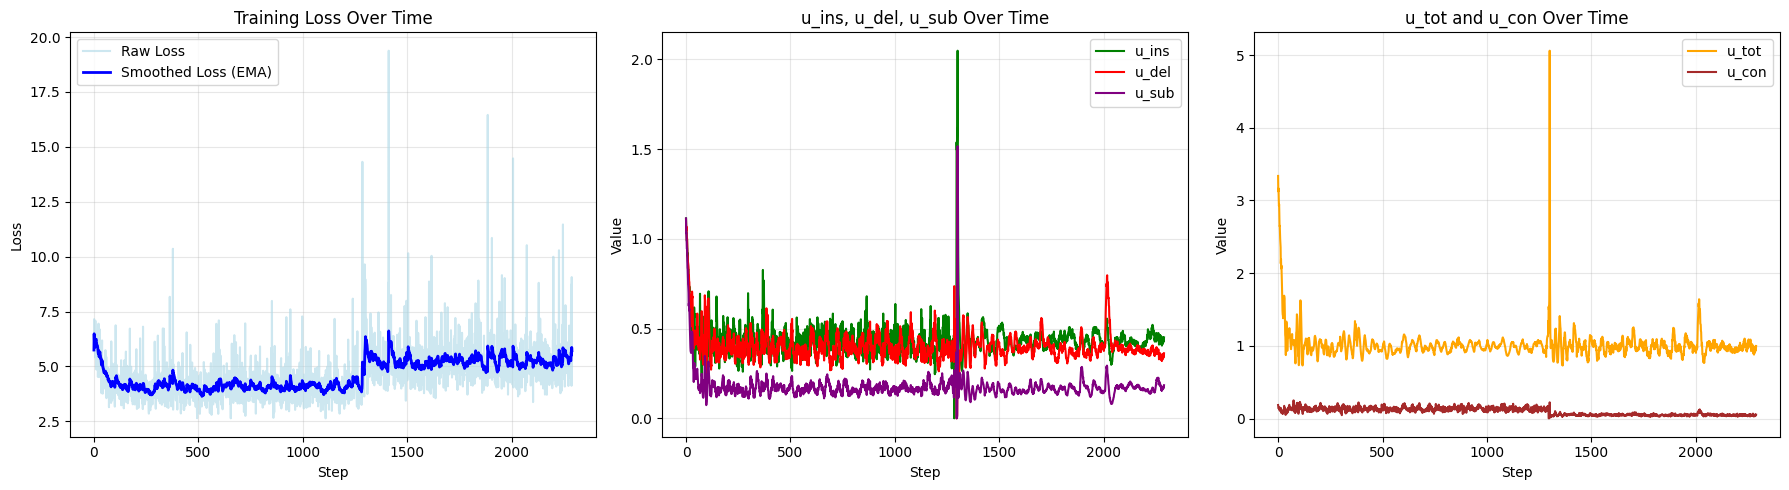

In [7]:
# Visualize the training metrics

import pandas as pd
import matplotlib.pyplot as plt

# 1 row, 3 columns
plt.figure(figsize=(18, 5))

# 1. Plot loss (raw and smoothed)
plt.subplot(1, 3, 1)
plt.plot(metrics["loss"], label='Raw Loss', color='lightblue', alpha=0.6)
smoothed_losses = pd.Series(metrics["loss"]).ewm(alpha=0.1).mean()
plt.plot(smoothed_losses, label='Smoothed Loss (EMA)', color='blue', linewidth=2)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3); plt.legend()

# 2. Plot u_ins, u_del, u_sub
plt.subplot(1, 3, 2)
plt.plot(metrics["u_ins"], label='u_ins', color='green')
plt.plot(metrics["u_del"], label='u_del', color='red')
plt.plot(metrics["u_sub"], label='u_sub', color='purple')
plt.xlabel('Step'); plt.ylabel('Value'); plt.title('u_ins, u_del, u_sub Over Time')
plt.grid(True, alpha=0.3); plt.legend()

# 3. Plot u_tot and u_con
plt.subplot(1, 3, 3)
plt.plot(metrics["u_tot"], label='u_tot', color='orange')
plt.plot(metrics["u_con"], label='u_con', color='brown')
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('u_tot and u_con Over Time')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Sampling via First Order Euler Steps

sampling 과정에서는 학습된 marginal rate $u_t(x \mid x_t)$에 따라 Euler step을 반복해서 적용함으로써 base distribution $x_0 \sim p(x_0)$에서 target distribution $q(x_1)$로 sample을 transport한다. 보통 factorized probability path의 경우 sequence의 각 position에 대해 rate update equation을 독립적으로 적용하면 된다. 하지만 Edit Flows에서는 3가지 edit operation 모두를 고려해야 하며 각 position에서 이를 동시에 적용해야 한다. 우리는 논문에서 제공된 다음 recipe를 따르면 된다:

<img src="static/editflows-sampling.png" alt="description" style="max-width: 80%; box-sizing: border-box;">

*Taken from Appendix B of the Edit Flows paper*

In [8]:
# Helper functions for sampling the model

def apply_ins_del_operations(
    x_t: T["batch_size", "seq_len", "long"],
    ins_mask: T["batch_size", "seq_len", "bool"],
    del_mask: T["batch_size", "seq_len", "bool"],
    ins_tokens: T["batch_size", "seq_len", "long"],
    max_seq_len: int = 512,
    pad_token=GAP_TOKEN,
) -> T["batch_size", "max_new_len", "long"]:
    """
    Apply insertion and deletion operations to a sequence x_t based on the provided masks.
    """
    batch_size, seq_len = x_t.shape
    device = x_t.device

    # Handle simultaneous ins+del as substitutions
    replace_mask = ins_mask & del_mask
    x_t_modified = x_t.clone()
    x_t_modified[replace_mask] = ins_tokens[replace_mask]

    # Update ins/del masks after handling replacements
    eff_ins_mask = ins_mask & ~replace_mask
    eff_del_mask = del_mask & ~replace_mask

    # Compute new lengths after applying ins/del operations
    xt_pad_mask = (x_t == pad_token)  # (batch_size, seq_len)
    xt_seq_lens = (~xt_pad_mask).sum(dim=1)  # (batch_size,)
    new_lengths = xt_seq_lens + eff_ins_mask.sum(dim=1) - eff_del_mask.sum(dim=1)
    max_new_len = int(new_lengths.max().item())

    if max_new_len <= 0:
        print(f"Unexpected max_new_len <= 0: {max_new_len}, did we delete everything?")
        return cast(
            T["batch_size", "max_new_len", "long"],
            torch.full((batch_size, 1), pad_token, dtype=x_t.dtype, device=device),
        )

    # Pre-allocate result
    x_new = torch.full((batch_size, max_new_len), pad_token, dtype=x_t.dtype, device=device)

    # Compute positions
    batch_idx = torch.arange(batch_size, device=device).unsqueeze(1)    # (batch_size, 1)
    pos_idx = torch.arange(seq_len, device=device).unsqueeze(0)         # (1, seq_len)
    cum_del = torch.cumsum(eff_del_mask.float(), dim=1)                 # num del up to & incl. current pos
    cum_ins = torch.cumsum(eff_ins_mask.float(), dim=1)                 # num ins up to & incl. current pos
    cum_ins_before = F.pad(cum_ins[:, :-1], (1, 0), value=0)            # num ins before current pos
    
    # Place non-deleted tokens
    new_pos = pos_idx + cum_ins_before - cum_del                            # new pos of tokens shifted by ins/del
    keep_mask = ~eff_del_mask & (new_pos >= 0) & (new_pos < max_new_len)    # tokens to keep (non-deleted)
    if keep_mask.any():
        x_new[batch_idx.expand(-1, seq_len)[keep_mask], new_pos[keep_mask].long()] = x_t_modified[keep_mask]

    # Place insertions
    if eff_ins_mask.any():
        ins_pos = new_pos + 1                                               # insertions go 1 after new shifted pos
        ins_valid = eff_ins_mask & (ins_pos >= 0) & (ins_pos < max_new_len) # tokens to insert
        if ins_valid.any():
            x_new[batch_idx.expand(-1, seq_len)[ins_valid], ins_pos[ins_valid].long()] = ins_tokens[ins_valid]
    
    if max_new_len > max_seq_len:
        print(f"Warning: max_new_len {max_new_len} exceeds max_seq_len {max_seq_len}, truncating.")
        max_new_len = max_seq_len
    
    return cast(
        T["batch_size", "max_new_len", "long"],
        x_new[:, :max_new_len],
    )

def get_adaptive_h(h: float, t: torch.Tensor, scheduler: KappaScheduler):
    coeff = (1 - scheduler(t)) / scheduler.derivative(t)
    _h = h * torch.ones_like(t, device=t.device)
    h_adapt = torch.minimum(_h, coeff)
    return h_adapt

def load_model_state(model_name: str):
    checkpoint = torch.load(model_name, map_location=device)
    model = SimpleEditFlowsTransformer(
        vocab_size=checkpoint['vocab_size'],
        hidden_dim=checkpoint['hidden_dim'],
        num_layers=checkpoint['num_layers'],
        num_heads=checkpoint['num_heads'],
        max_seq_len=checkpoint['max_seq_len'],
        bos_token_id=checkpoint['bos_token_id'],
        pad_token_id=checkpoint['pad_token_id'],
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    optim = torch.optim.Adam(model.parameters(), lr=0.0001)
    optim.load_state_dict(checkpoint['optimizer_state_dict'])
    return model.to(device), optim

In [9]:
# (Optional) Save / Load the model state
from pathlib import Path

save_model = True
load_model = False
overwrite = True

save_dir = Path(f"results/target_shift")
model_name = Path(f"seq2seq_prior.pt")

if save_model:
    save_path = save_dir / model_name
    if not overwrite:
        assert not save_path.exists(), f"Model file {save_path} already exists. Please choose a different name."
    assert save_path.parent.exists(), f"Directory {save_path.parent} does not exist. Please create it first."
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optim.state_dict(),
        'vocab_size': model.V,
        'hidden_dim': model.H,
        # 'num_layers': model.num_layers,  #####
        # 'num_heads': model.num_heads,
        # 'max_seq_len': model.max_seq_len,
        # 'bos_token_id': model.bos_token_id,
        # 'pad_token_id': model.pad_token_id,
    }, save_path)
    print(f"Model saved to {save_path}")

if load_model:
    save_path = save_dir / model_name
    assert save_path.exists(), f"Model file {save_path} does not exist."
    model, optim = load_model_state(save_path)
    print(f"Model loaded from {save_path}")

Model saved to results/target_shift/seq2seq_prior.pt


In [10]:
# Sampling loop

n_steps = 1000
n_samples = 4
t_min = 0.0

model.eval()

default_h = 1 / n_steps
t = t_min * torch.ones(n_samples, 1)

# Sample initial x_t = x_0 from the coupling
x_0, _, _, _, _, _ = make_batch(
    batch_size=n_samples,
    min_length=64,  ##min_seq_len,
    max_length=128,  ##max_seq_len,
    vocab_size=V,
    coupling=coupling,
    seq_align_fn=seq_align_fn,
    num_cycles_fn=num_cycles_fn,
    x_int_fn=x_int_fn,
)

x_t = x_0.clone()
x_pad_mask = (x_t == PAD_TOKEN) # Create padding mask for x_t
x_ts = [x_t.clone()]

with tqdm(desc="Euler Sampling") as pbar:
    while t.max() <= 1 - default_h:
        u_t, ins_probs, sub_probs = model.forward(
            cast(T["batch_size", "x_seq_len", "long"], x_t.to(device)),
            cast(T["batch_size", 1, "float"], t.to(device)),
            cast(T["batch_size", "x_seq_len", "bool"], x_pad_mask.to(device)),
        )
        lambda_ins = u_t[:, :, 0].cpu()     # Insertion rate        (n_samples, x_seq_len)
        lambda_sub = u_t[:, :, 1].cpu()     # Substitution rate     (n_samples, x_seq_len)
        lambda_del = u_t[:, :, 2].cpu()     # Deletion rate         (n_samples, x_seq_len)

        adapt_h = get_adaptive_h(default_h, t, scheduler)

        # Sample insertions and deletion/substitutions based on rates
        ins_mask = torch.rand(
            size=lambda_ins.shape, device=lambda_ins.device) < 1 - torch.exp(-adapt_h * lambda_ins)
        del_sub_mask = torch.rand(
            size=lambda_sub.shape, device=lambda_sub.device
        ) < 1 - torch.exp(-adapt_h * (lambda_sub + lambda_del))

        # For deletion/substitution, sample based on the relative rates
        prob_del = torch.where(
            del_sub_mask, lambda_del / (lambda_sub + lambda_del), torch.zeros_like(lambda_del))
        del_mask = torch.bernoulli(prob_del).bool()
        sub_mask = del_sub_mask & ~del_mask
        assert sub_mask.sum() + del_mask.sum() == del_sub_mask.sum()

        # Only sample tokens for non-pad positions, fill pad positions with PAD_TOKEN
        ins_tokens = torch.full(ins_probs.shape[:2], PAD_TOKEN, dtype=torch.long)
        sub_tokens = torch.full(sub_probs.shape[:2], PAD_TOKEN, dtype=torch.long)
        non_pad_mask = ~x_pad_mask
        if non_pad_mask.any():
            ins_sampled = torch.multinomial(ins_probs[non_pad_mask].cpu(), num_samples=1, replacement=True).squeeze(-1)
            sub_sampled = torch.multinomial(sub_probs[non_pad_mask].cpu(), num_samples=1, replacement=True).squeeze(-1)
            ins_tokens[non_pad_mask] = ins_sampled
            sub_tokens[non_pad_mask] = sub_sampled

        # Apply operations based on masks
        x_t[sub_mask] = sub_tokens[sub_mask]
        x_t = apply_ins_del_operations(
            cast(T["batch_size", "seq_len", "long"], x_t),
            cast(T["batch_size", "seq_len", "bool"], ins_mask),
            cast(T["batch_size", "seq_len", "bool"], del_mask),
            cast(T["batch_size", "seq_len", "long"], ins_tokens),
            max_seq_len=256,  #model.max_seq_len,
            pad_token=PAD_TOKEN,
        )
        x_pad_mask = (x_t == PAD_TOKEN)  # Update padding mask after operations

        t = t + adapt_h
        x_ts.append(x_t.clone())
        pbar.update(1)

/tmp/ipykernel_81239/3703577141.py:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z1_list.append(torch.tensor(z1, dtype=torch.long))
/tmp/ipykernel_81239/3703577141.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z0_list.append(torch.tensor(z0, dtype=torch.long))
Euler Sampling: 1000it [00:26, 37.69it/s]


<BOS>..*'#16=BHUPZ^`esiry.u|x|....qnpoiaVKLH<;94+'.%...................+)%3:EFSNππππππππππππππππππππππππππππππππππππππππππππππ
...*1<BOS>TSBHUPZ^`e.isi.K.~#|x|...q.T.n/..oiVKH<94+'.%Q!.....zU.(..5.......Z.%C.%:EFSUNπππππππππππππππππππππππππππππππππππππππππππππππ

<BOS>..0-)5MWVeow.~....ztsoj_WIF-3("............#.&.5:GN^ddwyu.x.w.v|pkcPQ>4+πππππππππππππππππππππππππππππππππππππππππππππππππ
Q..<0.<BOS>:N5MWow.~.a.!.-.ztsbj.W|F-3.("...........#.Q59:G^fddwyu.x.../wv|p..kcQ>4r.+`ππππππππππππππππππππππππππππππππππππππππππππππππ

<BOS>bjqv{yx.~pvz}yitxbcbTJI<;2-( ..................!..*A:F>CTO_jprnxtz..|.|.svz{dchYSHB?5?().....................#.1,CEPVVa`m
<BOS>..jqv{y.`~pv.yiv.cbTJIBfs<.2-( ....9."........K..R!.AC>CT_jprnxtz.|..f|.svz{dccYS.BgPHB.?5).................#.1C}EPVg[mπππππππππππ

<BOS>~..uz|jvkki]`RMSA>=6$++'#.......................",%*DBLATKIh\hlrnrwzxx..{....xulyge^oVOLG=:8/&/,.......................ππ
.8~.ujvkqkh].Q.`R8Ml.SA=$+k'#.....tX...<c...........FX?Y",%*DB=ATK]Ih\B.hlx.nrw.z

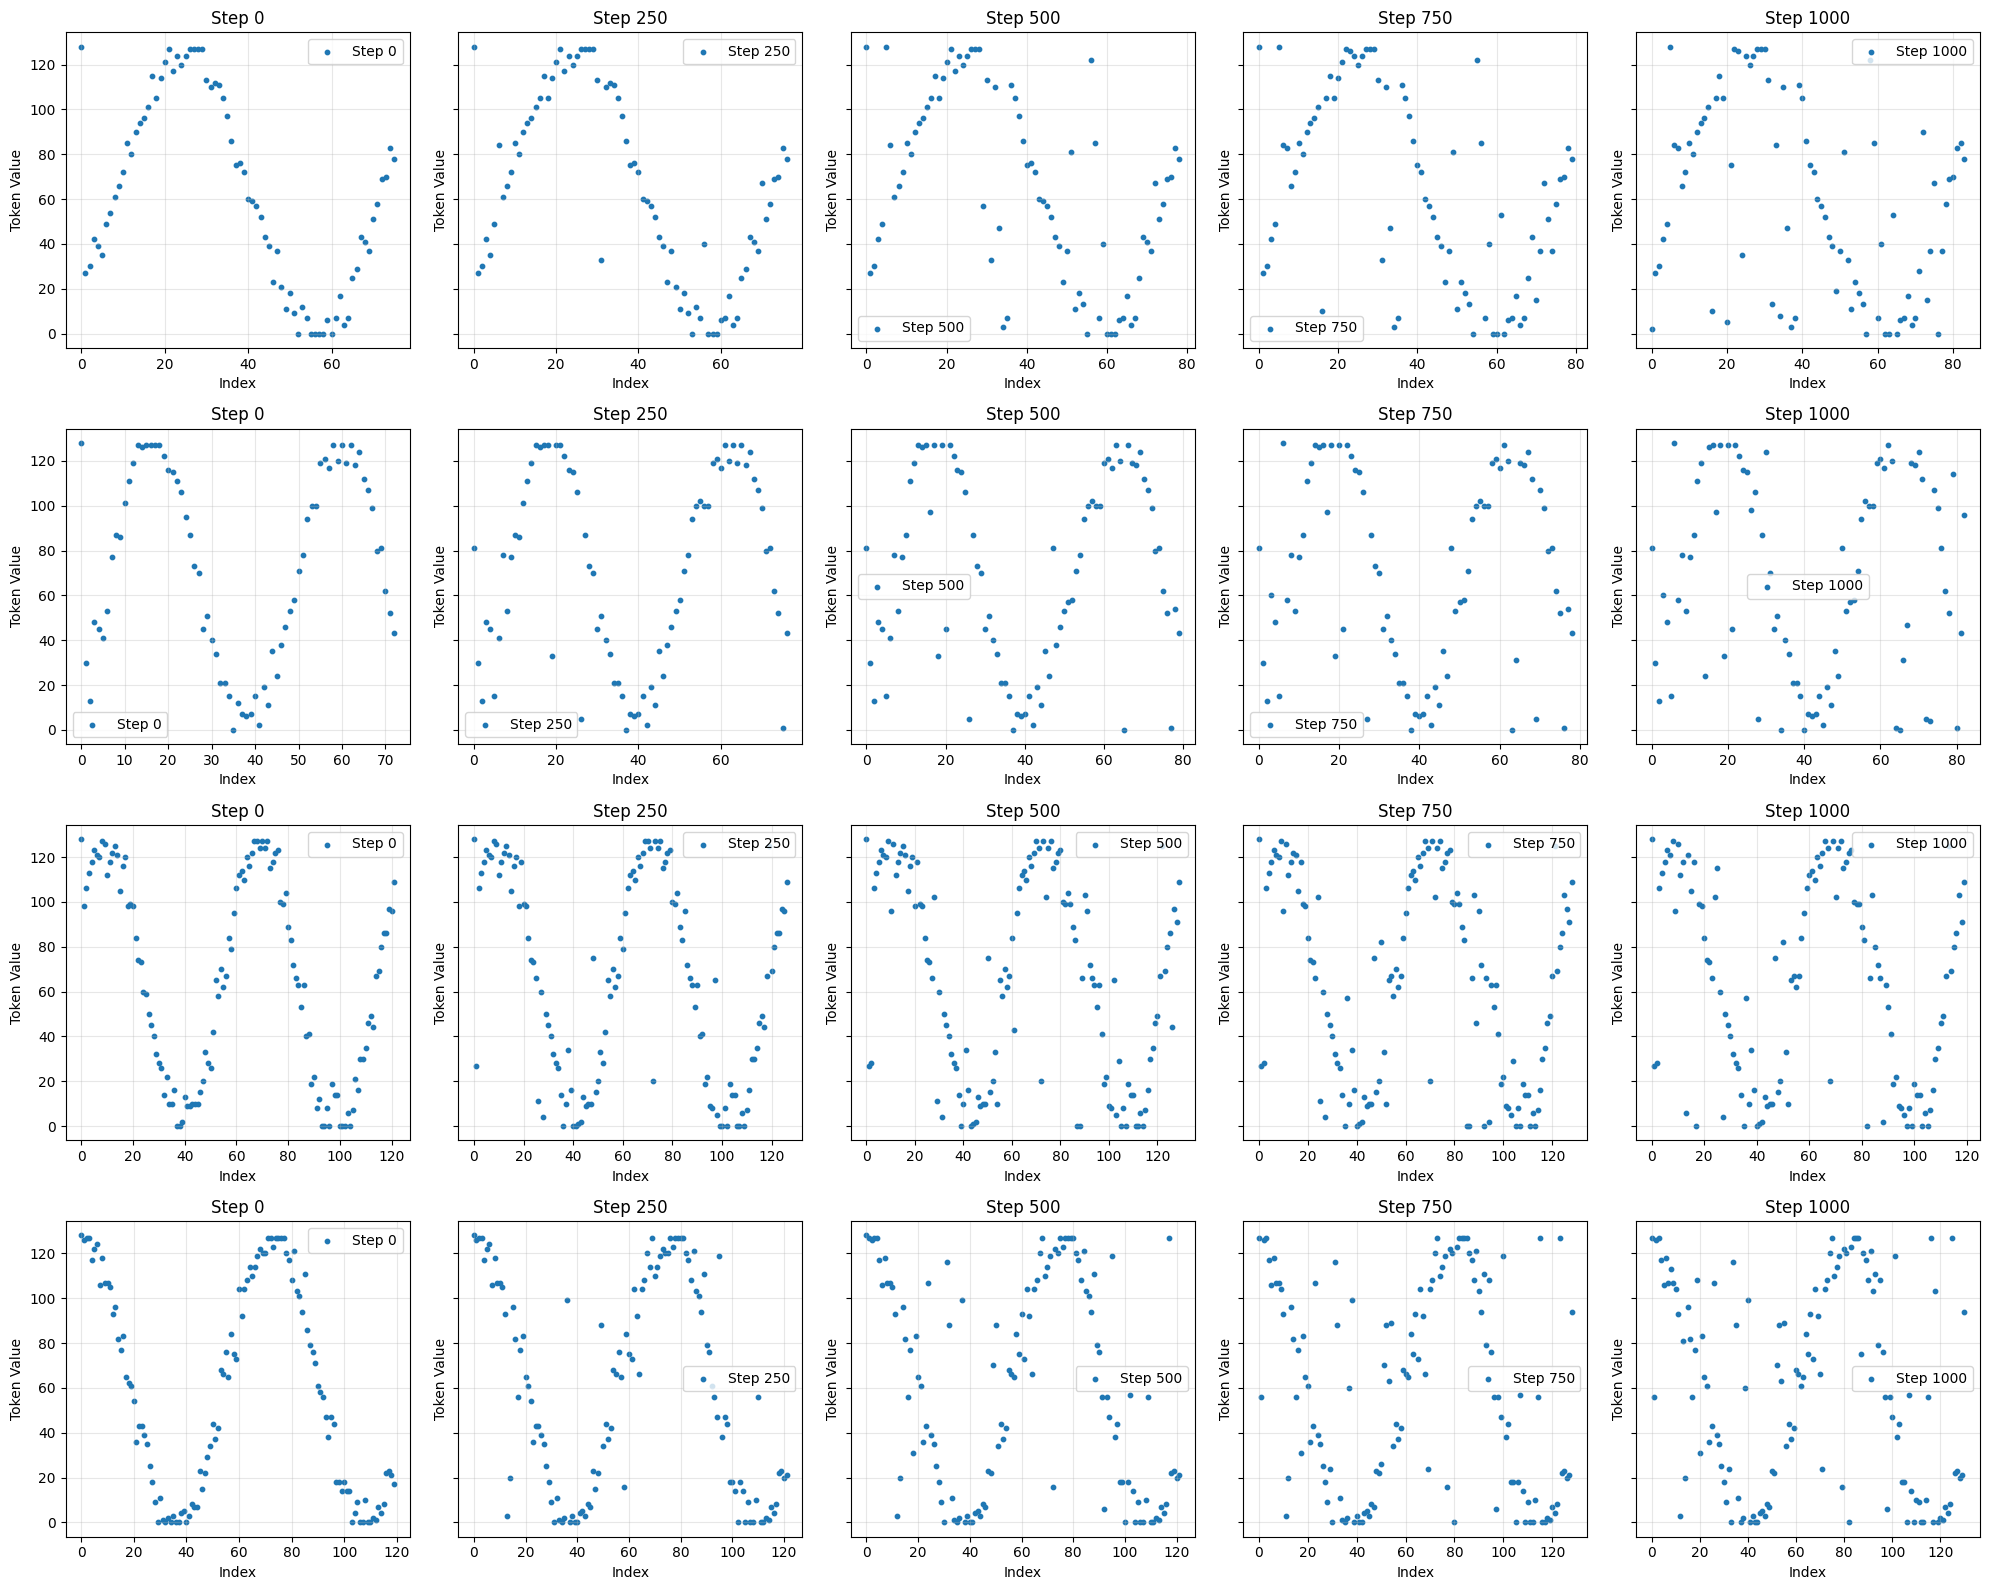

In [11]:
# Visualize the sampled sequences

n_seqs_to_plot = 5
seq_indices = np.linspace(0, len(x_ts) - 1, n_seqs_to_plot, dtype=int)

fig, ax = plt.subplots(n_samples, n_seqs_to_plot, figsize=(20, 4*n_samples), sharey=True)

for j in range(n_samples):
    pretty_print(x_ts[0][j], compact=True)
    pretty_print(x_ts[-1][j], compact=True)
    print()

    seqs = [x_ts[i][j].cpu().numpy().squeeze() for i in seq_indices]

    for i, seq in enumerate(seqs):
        y = seq[seq != PAD_TOKEN]  # Remove padding token
        x = np.arange(len(y))
        ax[j,i].scatter(x, y, label=f"Step {seq_indices[i]}", s=10)
        ax[j,i].set_title(f"Step {seq_indices[i]}")
        ax[j,i].set_xlabel("Index")
        ax[j,i].set_ylabel("Token Value")
        ax[j,i].grid(True, alpha=0.3)
        ax[j,i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Make video animation of the edit flows through sampling steps
from matplotlib.animation import FuncAnimation

# n_samples columns, 1 row, all samples animated together
fig, axes = plt.subplots(1, n_samples, figsize=(6*n_samples, 6), sharey=True)
if n_samples == 1:
    axes = [axes]

def update_all(frame):
    for sample_idx in range(n_samples):
        ax = axes[sample_idx]
        ax.clear()
        y = x_ts[frame][sample_idx].cpu().numpy().squeeze()
        y = y[y != PAD_TOKEN]  # Remove padding token
        x = np.arange(len(y))
        ax.scatter(x, y, s=10)
        ax.set_title(f"Sample {sample_idx} - Step {frame}")
        ax.set_xlabel("Index")
        ax.set_ylabel("Token Value")
        ax.grid(True, alpha=0.3)
        ax.legend([f"Time Step: {frame}"])

anim = FuncAnimation(fig, update_all, frames=len(x_ts), repeat=False, interval=100)
anim.save("editflow_anim.mp4", writer='ffmpeg', fps=n_steps // 10)
plt.close(fig)  # Prevents duplicate static plot display